В этом блокноте фитируется $\epsilon(\omega)$ по коэффициентам отражения и пропускания графена разной толщины на полипропиленовой плёнке в зависимости от частоты

Котликов, 2021
1) задача определения параметров пленки по спектрам отражения и пропускания является типичной некорректной обратной задачей синтеза, неимеющей однозначного решения. Ее решение существенно зависит от наличия априорной информации о специфических особенностях исследуемых пленок и выбора метода решения.

Основная проблема - выбор числа точек регрессии, чтобы минимизировать случайную погрешность и изменение $\epsilon(\omega)$

Вопросы:
1) поглощение

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
import pandas as pd
import glob
import os
import sys
sys.path.append(r'C:\Users\belco\Documents\Graphene\Graphene-films-plasmon-refractometry\lib')
from reflect import reflect3, reflect4


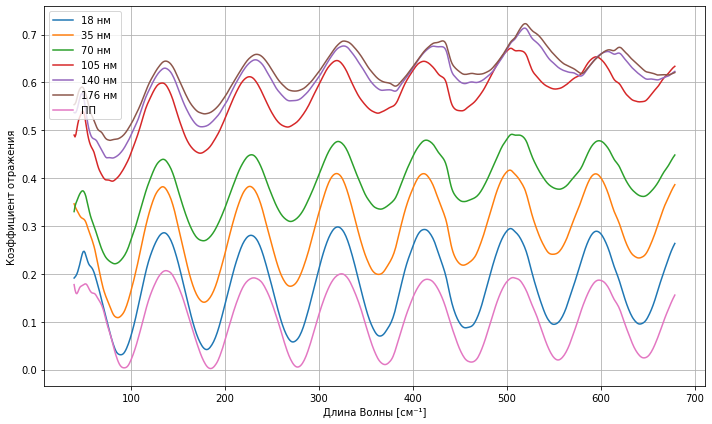

In [15]:
# Step 1: Load all 7 files into a list
file_paths = glob.glob(r"C:/Users/belco/Documents/Graphene/Data/Dispersion_PP_40/Ref_dis/*.dpt")  # Adjust the path and extension if needed

# Step 2: Initialize a plot
plt.figure(figsize=(10, 6))
labels = ['18 нм', '35 нм', '70 нм', '105 нм', '140 нм', '176 нм', 'ПП']

# Step 3: Loop through files and plot each
for i, file in enumerate(file_paths):
    data = pd.read_csv(file, header=None, sep='\t', decimal='.')  # Read file assuming no header
    wavelength = data[0]  # First column: Wavelength [cm⁻¹]
    reflectance = data[1]  # Second column: Reflectance R
    plt.plot(wavelength, reflectance, label=labels[i])  # Plot with label

# Step 4: Customize the plot
plt.xlabel("Длина Волны [см⁻¹]")
plt.ylabel("Коэффициент отражения")
#plt.title("Reflectance vs. Wavelength")
plt.legend()  # Add legend for dataset distinction
plt.grid(True)  # Optional: Add grid
plt.tight_layout()

# Step 5: Display the plot
plt.show()


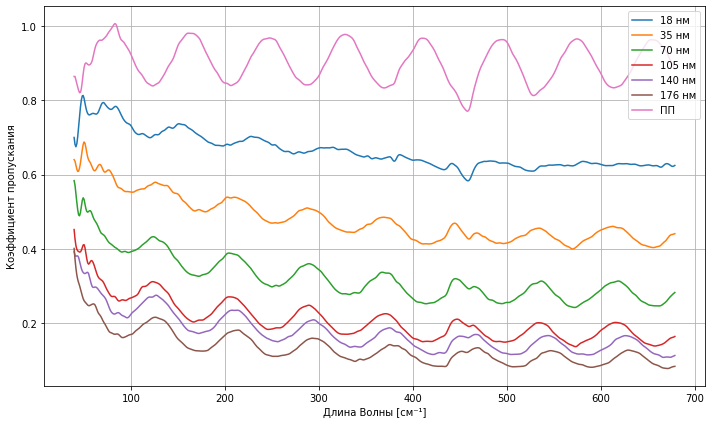

In [16]:
# Step 1: Load all 7 files into a list
file_paths = glob.glob(r"C:/Users/belco/Documents/Graphene/Data/Dispersion_PP_40/Transm_dis/*.dpt")  # Adjust the path and extension if needed

# Step 2: Initialize a plot
plt.figure(figsize=(10, 6))
labels = ['18 нм',  '35 нм', '70 нм', '105 нм', '140 нм', '176 нм', 'ПП']

# Step 3: Loop through files and plot each
for i, file in enumerate(file_paths):
    data = pd.read_csv(file, header=None, sep='\t', decimal='.')  # Read file assuming no header
    wavelength = data[0]  # First column: Wavelength [cm⁻¹]
    reflectance = data[1]  # Second column: Reflectance R
    plt.plot(wavelength, reflectance, label = labels[i])  # Plot with label

# Step 4: Customize the plot
plt.xlabel("Длина Волны [см⁻¹]")
plt.ylabel("Коэффициент пропускания")
#plt.title("Reflectance vs. Wavelength")
plt.legend()  # Add legend for dataset distinction
plt.grid(True)  # Optional: Add grid
plt.tight_layout()

# Step 5: Display the plot
plt.show()



In [17]:
eps_air = 1 
eps_PP = (1.498+1j*14e-4)**2                                  # диэлектрическая проницаемость воздуха (1.00027717)                  # InSb на 197мкм табличное значение
PP_thckn = 40e-6
g_thckn = 35e-9

def reflect_gr_PP(teta, _gr_re, _gr_im, wavelength):
    eps_re = np.array([eps_air.real, _gr_re, eps_PP.real, eps_air.real])
    eps_im = np.array([eps_air.imag, _gr_im, eps_PP.imag, eps_air.imag])
    return reflect_n(4, teta, np.array([PP_thckn, g_thckn]), eps_re, eps_im, wavelength)
def reflect_PP(teta, wavelength):
    eps_re = np.array([eps_air.real, eps_PP.real, eps_air.real])
    eps_im = np.array([eps_air.imag, eps_PP.imag, eps_air.imag])
    return reflect_n(3, teta, np.array([PP_thckn]), eps_re, eps_im, wavelength)

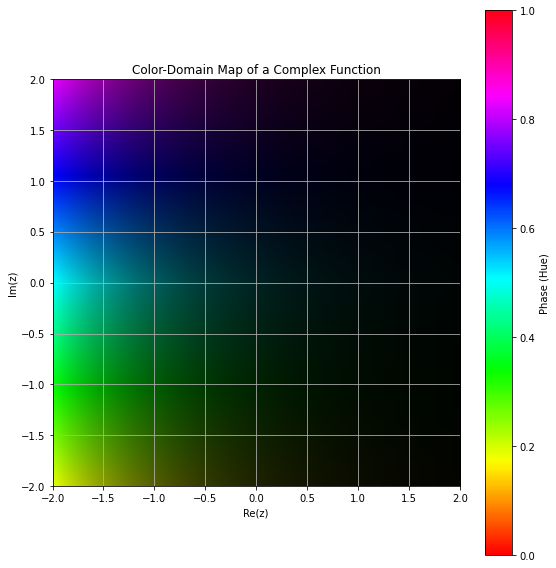

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb

# Define a complex-valued function f(x, y)
def complex_function(x, y):
    z = x + 1j * y  # Create a complex number z = x + iy
    return np.exp(-z)  # Example function

# Create a grid of x and y values
x = np.linspace(-2, 2, 500)  # X range
y = np.linspace(-2, 2, 500)  # Y range
X, Y = np.meshgrid(x, y)  # Create grid

# Compute the complex function on the grid
Z = complex_function(X, Y)

# Extract magnitude and phase
magnitude = np.abs(Z)  # Magnitude
phase = np.angle(Z)    # Phase (angle in radians)

# Normalize magnitude for brightness (value in HSV)
magnitude_normalized = magnitude / np.max(magnitude)

# Map phase (-π to π) to hue (0 to 1)
hue = (phase + np.pi) / (2 * np.pi)

# Create HSV image
hsv_image = np.zeros((*Z.shape, 3))  # HSV has 3 channels
hsv_image[..., 0] = hue              # Hue
hsv_image[..., 1] = 1.0              # Saturation (fully saturated)
hsv_image[..., 2] = magnitude_normalized  # Value (normalized magnitude)

# Convert HSV to RGB for plotting
rgb_image = hsv_to_rgb(hsv_image)

# Plot the color-domain map
plt.figure(figsize=(8, 8))
plt.imshow(rgb_image, extent=[x.min(), x.max(), y.min(), y.max()])
plt.title("Color-Domain Map of a Complex Function")
plt.xlabel("Re(z)")
plt.ylabel("Im(z)")
plt.colorbar(plt.cm.ScalarMappable(cmap="hsv"), label="Phase (Hue)")
plt.grid()
plt.tight_layout()
plt.show()
